# SPA-v2 Results Analysis
Median eval rank (r=8) + rank-weighted aggregation + adaptive β

In [2]:
import json, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

REWORK   = '/home/sp2ai/FedLLM-Re/rework'
V1_DIR   = os.path.join(REWORK, 'results')
V2_DIR   = os.path.join(REWORK, 'results_v2')

METHOD_LABELS = {
    'homo_r4':    'FedAvg r=4',
    'homo_r8':    'FedAvg r=8',
    'hetero_pad': 'Hetero-Pad',
    'flexlora':   'FlexLoRA',
    'hetlora': 'HetLora',
    'hetero_spa': 'SPA',
    'spa_m':      'SPA-M (Ours)',
}
METHOD_ORDER = ['homo_r4','homo_r8','hetero_pad','flexlora','hetero_spa','spa_m']
COLORS = {
    'homo_r4':    '#bbbbbb',
    'homo_r8':    '#888888',
    'hetero_pad': '#4393c3',
    'flexlora':   '#f4a582',
    'hetero_spa': '#2ca02c',
    'spa_m':      '#d62728',
}
print('Config ready.')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/conda/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/conda/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.10/site-packages/traitlets/config/application.py", line 976, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.10/site-packages/ipykernel/

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/conda/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/conda/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.10/site-packages/traitlets/config/application.py", line 976, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.10/site-packages/ipykernel/

AttributeError: _ARRAY_API not found

Config ready.


In [3]:
def load_results(base_dir, dataset):
    records = []
    for f in glob.glob(os.path.join(base_dir, dataset, '*.json')):
        try:
            d = json.load(open(f))
            records.append(d)
        except Exception as e:
            print(f'Skip {f}: {e}')
    return records

v2_yelp = load_results(V2_DIR, 'yelp')
v1_yelp = load_results(V1_DIR, 'yelp')
print(f'V2 Yelp: {len(v2_yelp)} files')
print(f'V1 Yelp: {len(v1_yelp)} files')

V2 Yelp: 51 files
V1 Yelp: 58 files


In [4]:
K = 5  # last-K rounds for mean

def to_df(results, metrics, k=K):
    rows = []
    for d in results:
        rounds = d['rounds']
        last   = rounds[-1]
        best_acc      = max(r.get('accuracy', 0) for r in rounds)
        mean_lastk    = float(np.mean([r.get('accuracy', 0) for r in rounds[-k:]]))
        row = {
            'method': d['method'], 'alpha': d['alpha'], 'seed': d['seed'],
            'best_accuracy':   best_acc,
            'mean_lastk_acc':  mean_lastk,
        }
        for m in metrics:
            row[m] = last.get(m, np.nan)
        rows.append(row)
    return pd.DataFrame(rows)

v2_df = to_df(v2_yelp, ['accuracy','f1_macro','avg_loss','perplexity'])
v1_df = to_df(v1_yelp, ['accuracy','f1_macro','avg_loss','perplexity'])

print(f'V2 methods/seeds available (mean over last {K} rounds added):')
print(v2_df.groupby(['method','alpha']).size().unstack(fill_value=0))

V2 methods/seeds available (mean over last 5 rounds added):
alpha       0.1  0.5
method              
flexlora      5    5
hetero_pad    5    5
hetero_spa    3    5
hetlora       3    0
homo_r8       5    5
spa_m         5    5


In [5]:
def summary_table(df, alpha, scale=100):
    sub = df[df['alpha']==alpha]
    rows = []
    for m in METHOD_ORDER:
        g = sub[sub['method']==m]
        if g.empty: continue
        final = g['accuracy'].dropna().values * scale
        best  = g['best_accuracy'].dropna().values * scale
        ml5   = g['mean_lastk_acc'].dropna().values * scale
        rows.append({
            'Method':       METHOD_LABELS.get(m, m),
            f'Mean-L{K} Acc (★)': f'{ml5.mean():.1f}±{ml5.std():.1f}',
            'Final Acc':    f'{final.mean():.1f}±{final.std():.1f}',
            'Best Acc':     f'{best.mean():.1f}±{best.std():.1f}',
            'n': len(g)
        })
    return pd.DataFrame(rows).set_index('Method')

for alpha in [0.1, 0.5]:
    print(f'\n=== V2 Yelp α={alpha} ===')
    display(summary_table(v2_df, alpha))


=== V2 Yelp α=0.1 ===


,Mean-L5 Acc (★),Final Acc,Best Acc,n
Method,,,,
FedAvg r=8,42.2±2.7,39.6±12.8,54.1±3.3,5
Hetero-Pad,42.5±3.4,37.1±13.7,56.1±1.0,5
FlexLoRA,41.0±4.1,36.0±12.1,53.7±2.9,5
SPA,41.6±3.6,46.2±6.2,52.7±1.2,3
SPA-M (Ours),41.4±3.8,36.0±12.8,53.9±3.2,5



=== V2 Yelp α=0.5 ===


,Mean-L5 Acc (★),Final Acc,Best Acc,n
Method,,,,
FedAvg r=8,52.4±2.1,56.4±3.1,59.9±1.3,5
Hetero-Pad,48.9±4.3,51.3±5.5,57.4±2.3,5
FlexLoRA,51.3±3.3,53.1±4.3,59.4±2.3,5
SPA,50.6±4.1,52.2±4.8,59.6±2.7,5
SPA-M (Ours),51.6±3.5,52.1±4.0,60.1±2.4,5


## Metric Comparison: Mean-L5 vs Final vs Best

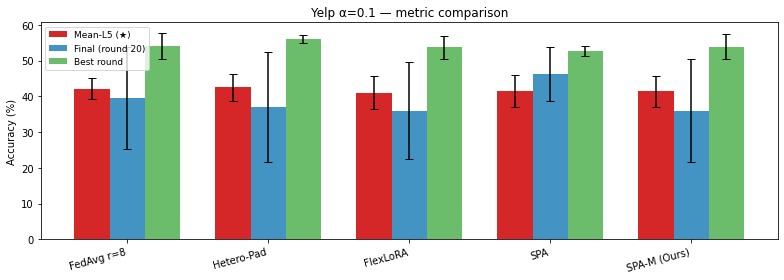


Std across seeds (lower = more stable) — α=0.1:


,Mean-L5 std,Final std,Best std
Method,,,
FedAvg r=8,3.00,14.28,3.71
Hetero-Pad,3.82,15.34,1.16
FlexLoRA,4.61,13.55,3.27
SPA,4.46,7.60,1.48
SPA-M (Ours),4.23,14.36,3.56


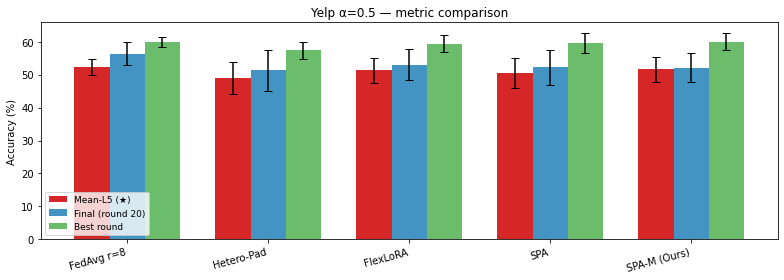


Std across seeds (lower = more stable) — α=0.5:


,Mean-L5 std,Final std,Best std
Method,,,
FedAvg r=8,2.34,3.47,1.45
Hetero-Pad,4.81,6.12,2.54
FlexLoRA,3.70,4.83,2.52
SPA,4.53,5.38,3.05
SPA-M (Ours),3.90,4.44,2.68


In [64]:
def plot_metric_comparison(df, alpha, scale=100, figsize=(11, 4)):
    """
    For each method, plot three bars: Mean-L5, Final, Best.
    Highlights which metric is most stable (lowest std across seeds).
    """
    sub = df[df['alpha']==alpha]
    methods  = [m for m in METHOD_ORDER if not sub[sub['method']==m].empty]
    labels   = [METHOD_LABELS.get(m, m) for m in methods]

    ml5_m,  ml5_s  = [], []
    fin_m,  fin_s  = [], []
    best_m, best_s = [], []

    for m in methods:
        g = sub[sub['method']==m]
        ml5_m.append(g['mean_lastk_acc'].mean() * scale)
        ml5_s.append(g['mean_lastk_acc'].std()  * scale)
        fin_m.append(g['accuracy'].mean()        * scale)
        fin_s.append(g['accuracy'].std()          * scale)
        best_m.append(g['best_accuracy'].mean()   * scale)
        best_s.append(g['best_accuracy'].std()    * scale)

    x   = np.arange(len(methods))
    w   = 0.25
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x - w, ml5_m,  w, yerr=ml5_s,  label=f'Mean-L{K} (★)', color='#d62728', capsize=4)
    ax.bar(x,     fin_m,  w, yerr=fin_s,  label='Final (round 20)',color='#4393c3', capsize=4)
    ax.bar(x + w, best_m, w, yerr=best_s, label='Best round',      color='#2ca02c', capsize=4, alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_ylabel('Accuracy (%)'); ax.set_title(f'Yelp α={alpha} — metric comparison')
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

    # Print std summary — lower std = more stable metric
    print(f'\nStd across seeds (lower = more stable) — α={alpha}:')
    rows = []
    for i, m in enumerate(methods):
        rows.append({
            'Method': labels[i],
            f'Mean-L{K} std': f'{ml5_s[i]:.2f}',
            'Final std':     f'{fin_s[i]:.2f}',
            'Best std':      f'{best_s[i]:.2f}',
        })
    display(pd.DataFrame(rows).set_index('Method'))

plot_metric_comparison(v2_df, 0.1)
plot_metric_comparison(v2_df, 0.5)

## V1 vs V2 Comparison (SPA and SPA-M)

In [65]:
def compare_v1_v2(method, scale=100):
    rows = []
    for alpha in [0.1, 0.5]:
        for label, df in [('V1 (r=4 eval)', v1_df), ('V2 (r=8 eval)', v2_df)]:
            g = df[(df['method']==method) & (df['alpha']==alpha)]
            if g.empty: continue
            ml5  = g['mean_lastk_acc'].dropna().values * scale
            fin  = g['accuracy'].dropna().values       * scale
            best = g['best_accuracy'].dropna().values  * scale
            rows.append({
                'Version': label, 'α': alpha,
                f'Mean-L{K} (★)': f'{ml5.mean():.1f}±{ml5.std():.1f}',
                'Final':          f'{fin.mean():.1f}±{fin.std():.1f}',
                'Best':           f'{best.mean():.1f}±{best.std():.1f}',
                'n': len(g)
            })
    return pd.DataFrame(rows).set_index(['Version','α'])

print('=== SPA (hetero_spa) ===')
display(compare_v1_v2('hetero_spa'))

print('\n=== SPA-M ===')
display(compare_v1_v2('spa_m'))

=== SPA (hetero_spa) ===


,,Mean-L5 (★),Final,Best,n
Version,α,,,,
V1 (r=4 eval),0.1,39.4±2.7,40.9±11.2,53.0±2.2,5
V2 (r=8 eval),0.1,41.6±3.6,46.2±6.2,52.7±1.2,3
V1 (r=4 eval),0.5,50.5±5.1,53.5±5.4,57.7±3.8,5
V2 (r=8 eval),0.5,50.6±4.1,52.2±4.8,59.6±2.7,5



=== SPA-M ===


,,Mean-L5 (★),Final,Best,n
Version,α,,,,
V1 (r=4 eval),0.1,47.3±6.5,47.6±7.4,53.4±2.7,5
V2 (r=8 eval),0.1,41.4±3.8,36.0±12.8,53.9±3.2,5
V1 (r=4 eval),0.5,45.5±1.7,46.7±2.1,49.7±1.5,5
V2 (r=8 eval),0.5,51.6±3.5,52.1±4.0,60.1±2.4,5


## Convergence Curves — V2

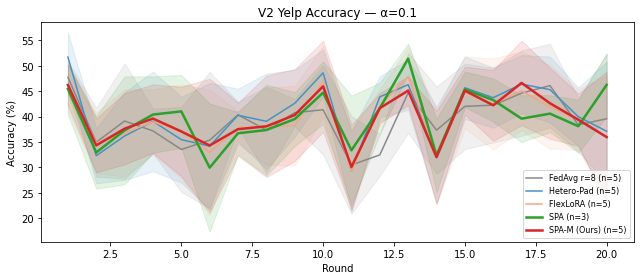

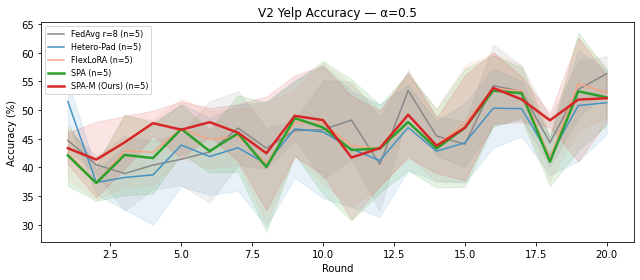

In [66]:
def plot_convergence(results, metric, alpha, title, ylabel, scale=100, figsize=(9,4)):
    fig, ax = plt.subplots(figsize=figsize)
    method_curves = {}
    for d in results:
        if d['alpha'] != alpha: continue
        curve = [r.get(metric, np.nan)*scale for r in d['rounds']]
        method_curves.setdefault(d['method'], []).append(curve)

    for method in METHOD_ORDER:
        if method not in method_curves: continue
        curves = np.array(method_curves[method])
        mean = np.nanmean(curves, axis=0)
        std  = np.nanstd(curves, axis=0)
        x = np.arange(1, len(mean)+1)
        lw = 2.5 if method in ('hetero_spa','spa_m') else 1.5
        ax.plot(x, mean, label=f"{METHOD_LABELS.get(method,method)} (n={len(curves)})",
                color=COLORS[method], lw=lw)
        ax.fill_between(x, mean-std, mean+std, alpha=0.12, color=COLORS[method])

    ax.set_xlabel('Round'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8, loc='best')
    plt.tight_layout(); plt.show()

plot_convergence(v2_yelp, 'accuracy', 0.1, 'V2 Yelp Accuracy — α=0.1', 'Accuracy (%)')
plot_convergence(v2_yelp, 'accuracy', 0.5, 'V2 Yelp Accuracy — α=0.5', 'Accuracy (%)')

## Side-by-Side: V1 vs V2 Convergence

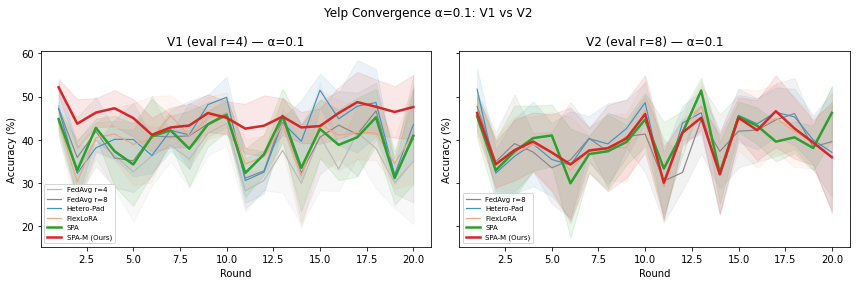

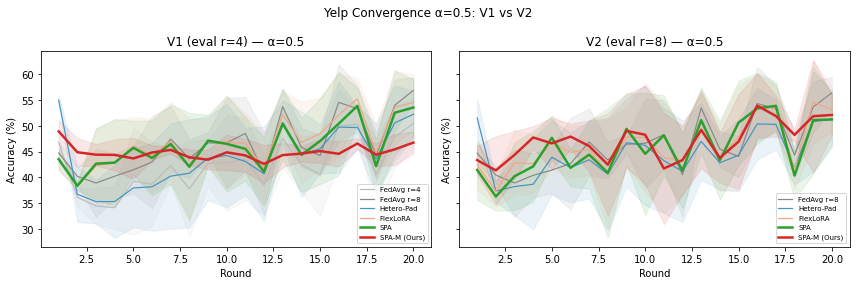

In [58]:
def plot_v1_v2_side(method, alpha):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, (results, label) in zip(axes, [(v1_yelp,'V1 (eval r=4)'), (v2_yelp,'V2 (eval r=8)')]):
        for m in METHOD_ORDER:
            curves = []
            for d in results:
                if d['method']==m and d['alpha']==alpha:
                    curves.append([r.get('accuracy',np.nan)*100 for r in d['rounds']])
            if not curves: continue
            arr = np.array(curves)
            mean = np.nanmean(arr, axis=0)
            std  = np.nanstd(arr, axis=0)
            x = np.arange(1, len(mean)+1)
            lw = 2.5 if m in ('hetero_spa','spa_m') else 1.2
            ax.plot(x, mean, label=METHOD_LABELS.get(m,m), color=COLORS[m], lw=lw)
            ax.fill_between(x, mean-std, mean+std, alpha=0.1, color=COLORS[m])
        ax.set_title(f'{label} — α={alpha}')
        ax.set_xlabel('Round'); ax.set_ylabel('Accuracy (%)')
        ax.legend(fontsize=7)
    plt.suptitle(f'Yelp Convergence α={alpha}: V1 vs V2', fontsize=12)
    plt.tight_layout(); plt.show()

plot_v1_v2_side('all', 0.1)
plot_v1_v2_side('all', 0.5)

## Progress Check — Missing Runs

In [59]:
done = {(d['method'], d['alpha'], d['seed']) for d in v2_yelp}
missing = []
for m in ['hetero_spa','spa_m','homo_r8','flexlora','hetero_pad']:
    for a in [0.1, 0.5]:
        for s in [42, 43, 44, 45, 46]:
            if (m, a, s) not in done:
                missing.append(f'{m} α={a} seed={s}')

print(f'Done: {len(done)}/50')
print(f'Missing: {len(missing)}')
for r in missing:
    print(' ', r)

Done: 47/50
Missing: 3
  hetero_spa α=0.1 seed=44
  hetero_spa α=0.1 seed=46
  hetero_spa α=0.5 seed=44
